In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings

df = pd.read_csv("..\data\preprocessed\marketing_campaign_preprocessed.csv", encoding='ascii')
                 
print(df.shape)

(2229, 28)


In [2]:
rfm_df = df[['Recency', 'Total_Purchases', 'Total_Spending']].copy()
rfm_df.columns = ['Recency', 'Frequency', 'Monetary']

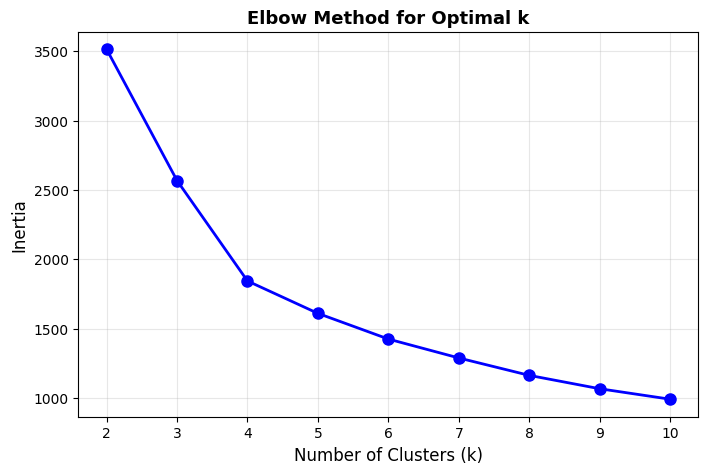

In [5]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df)

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
#k = 4 is optimal k

kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df['Cluster_4'] = kmeans_4.fit_predict(rfm_scaled)

cluster_summary_4 = rfm_df.groupby('Cluster_4')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_labels_4 = {}
for cluster in range(4):
    recency = cluster_summary_4.loc[cluster, 'Recency']
    frequency = cluster_summary_4.loc[cluster, 'Frequency']
    monetary = cluster_summary_4.loc[cluster, 'Monetary']
    
    # High-Value Loyal Recent: High frequency AND high monetary AND low recency
    if frequency > rfm_df['Frequency'].median() and monetary >= rfm_df['Monetary'].median() and recency < rfm_df['Recency'].median():
        cluster_labels_4[cluster] = 'High-Value Loyal Recent'
    # High-Value Loyal Inactive: High frequency AND high monetary AND high recency
    elif frequency >= rfm_df['Frequency'].median() and monetary >= rfm_df['Monetary'].median() and recency >= rfm_df['Recency'].median():
        cluster_labels_4[cluster] = 'High-Value Loyal Inactive'
    # At-Risk Inactive: Low frequency AND low monetary AND low recency
    elif frequency < rfm_df['Frequency'].median() and monetary < rfm_df['Monetary'].median() and recency < rfm_df['Recency'].median():
        cluster_labels_4[cluster] = 'At-Risk Inactive'
    else: #At-Risk Low-Engagement: Low frequency AND low monetary AND high recency 
        cluster_labels_4[cluster] = 'At-Risk Low-Engagement'

# Map labels
rfm_df['Segment'] = rfm_df['Cluster_4'].map(cluster_labels_4)

print('4-Cluster Interpretation:')
for cluster in sorted(cluster_labels_4.keys()):
    label = cluster_labels_4[cluster]
    r = cluster_summary_4.loc[cluster, 'Recency']
    f = cluster_summary_4.loc[cluster, 'Frequency']
    m = cluster_summary_4.loc[cluster, 'Monetary']
    print('Cluster ' + str(cluster) + ': ' + label + ' (R=' + str(round(r, 1)) + ', F=' + str(round(f, 1)) + ', M=' + str(round(m, 1)) + ')')

print('\
\
Segment Distribution:')
print(rfm_df['Segment'].value_counts())


4-Cluster Interpretation:
Cluster 0: High-Value Loyal Recent (R=22.6, F=20.7, M=24.7)
Cluster 1: High-Value Loyal Inactive (R=72.3, F=21.0, M=25.5)
Cluster 2: At-Risk Low-Engagement (R=75.3, F=8.5, M=12.5)
Cluster 3: At-Risk Inactive (R=25.0, F=7.5, M=11.4)
Segment Distribution:
Segment
High-Value Loyal Inactive    616
High-Value Loyal Recent      573
At-Risk Inactive             524
At-Risk Low-Engagement       516
Name: count, dtype: int64


<Figure size 1200x1000 with 0 Axes>

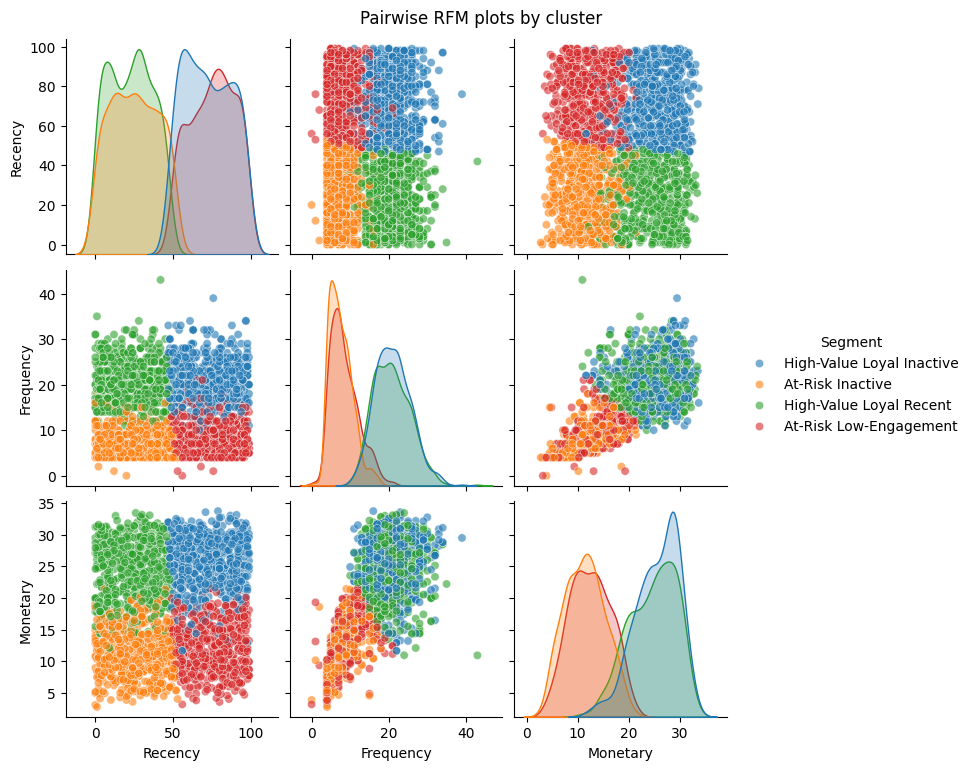

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_features = rfm_df[['Recency','Frequency','Monetary']]
rfm_scaled = scaler.fit_transform(rfm_features)

cluster_col = 'Segment'

plt.figure(figsize=(12,10))
sns.pairplot(rfm_df[['Recency','Frequency','Monetary', cluster_col]], hue=cluster_col, diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairwise RFM plots by cluster', y=1.02)
plt.show()


In [15]:
segment_mapping = rfm_df[['Segment']].copy()
df['Customer_Segment'] = segment_mapping['Segment'].values

#Demographic breakdown by segment
print('=' * 80)
print('DEMOGRAPHIC PROFILE BY SEGMENT')
print('=' * 80)

demographic_cols = ['Age', 'Education', 'Living_With', 'Family_Size', 'Children_at_home']

for col in demographic_cols:
    if col in df.columns:
        print(f'\n{col}:')
        if col == 'Age':
            bins = list(range(0, 110, 10))
            labels = [f'{i}-{i+9}' for i in range(0, 100, 10)]
            display_data = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
        else:
            display_data = df[col]

        # Calculate crosstab with the (possibly binned) data
        demo_breakdown = pd.crosstab(
            df['Customer_Segment'], 
            display_data, 
            margins=True, 
            normalize='index'
        ).round(3) * 100
        
        print(demo_breakdown)


DEMOGRAPHIC PROFILE BY SEGMENT

Age:
Age                        30-39  40-49  50-59  60-69  70-79  80-89
Customer_Segment                                                   
At-Risk Inactive             7.4   27.3   37.6   16.4   10.9    0.4
At-Risk Low-Engagement       6.0   23.3   33.3   22.3   14.1    1.0
High-Value Loyal Inactive    6.0   16.1   29.4   23.2   22.9    2.4
High-Value Loyal Recent      7.0   16.4   29.7   25.0   18.8    3.1
All                          6.6   20.5   32.3   21.8   17.0    1.8

Education:
Education                  Graduate   PhD  Postgraduate  Undergraduate
Customer_Segment                                                      
At-Risk Inactive               45.4  21.2          17.2           16.2
At-Risk Low-Engagement         49.6  18.8          16.9           14.7
High-Value Loyal Inactive      53.4  23.5          16.4            6.7
High-Value Loyal Recent        52.5  22.3          15.9            9.2
All                            50.4  21.6        

In [16]:
#Spending patterns by segment
print('\
' + '=' * 80)
print('SPENDING PATTERNS BY SEGMENT')
print('=' * 80)

spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
spending_summary = df.groupby('Customer_Segment')[spending_cols].mean().round(2)
print('\
Average Spending by Product Category:')
print(spending_summary)

print('\
\
Total Spending Summary:')
total_spending_summary = df.groupby('Customer_Segment')[['Total_Spending', 'Total_Purchases', 'Income']].agg(['mean', 'median', 'std']).round(2)
print(total_spending_summary)

SPENDING PATTERNS BY SEGMENT
Average Spending by Product Category:
                           MntWines  MntFruits  MntMeatProducts  \
Customer_Segment                                                  
At-Risk Inactive               2.97       1.11             2.61   
At-Risk Low-Engagement         3.27       1.23             2.90   
High-Value Loyal Inactive      6.10       3.26             5.38   
High-Value Loyal Recent        5.99       3.10             5.28   

                           MntFishProducts  MntSweetProducts  MntGoldProds  
Customer_Segment                                                            
At-Risk Inactive                      1.36              1.13          2.21  
At-Risk Low-Engagement                1.45              1.23          2.38  
High-Value Loyal Inactive             3.62              3.28          3.90  
High-Value Loyal Recent               3.43              3.07          3.82  
Total Spending Summary:
                          Total_Spending    

In [17]:
# Campaign response and engagement by segment
print('\
' + '=' * 80)
print('CAMPAIGN RESPONSE & ENGAGEMENT BY SEGMENT')
print('=' * 80)

campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']
campaign_summary = df.groupby('Customer_Segment')[campaign_cols].agg(['sum', 'mean']).round(3)
print('\
Campaign Acceptance Rates:')
print(campaign_summary)

print('\
\
Purchase Channel Preferences:')
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
channel_summary = df.groupby('Customer_Segment')[channel_cols].mean().round(2)
print(channel_summary)

print('\
\
Web Engagement:')
web_summary = df.groupby('Customer_Segment')[['NumWebVisitsMonth', 'Customer_Tenure_Days']].mean().round(2)
print(web_summary)


CAMPAIGN RESPONSE & ENGAGEMENT BY SEGMENT
Campaign Acceptance Rates:
                          AcceptedCmp1        AcceptedCmp2         \
                                   sum   mean          sum   mean   
Customer_Segment                                                    
At-Risk Inactive                     1  0.002            2  0.004   
At-Risk Low-Engagement               1  0.002            0  0.000   
High-Value Loyal Inactive           70  0.114           15  0.024   
High-Value Loyal Recent             72  0.126           13  0.023   

                          AcceptedCmp3        AcceptedCmp4         \
                                   sum   mean          sum   mean   
Customer_Segment                                                    
At-Risk Inactive                    42  0.080            6  0.011   
At-Risk Low-Engagement              29  0.056           20  0.039   
High-Value Loyal Inactive           43  0.070           73  0.119   
High-Value Loyal Recent          

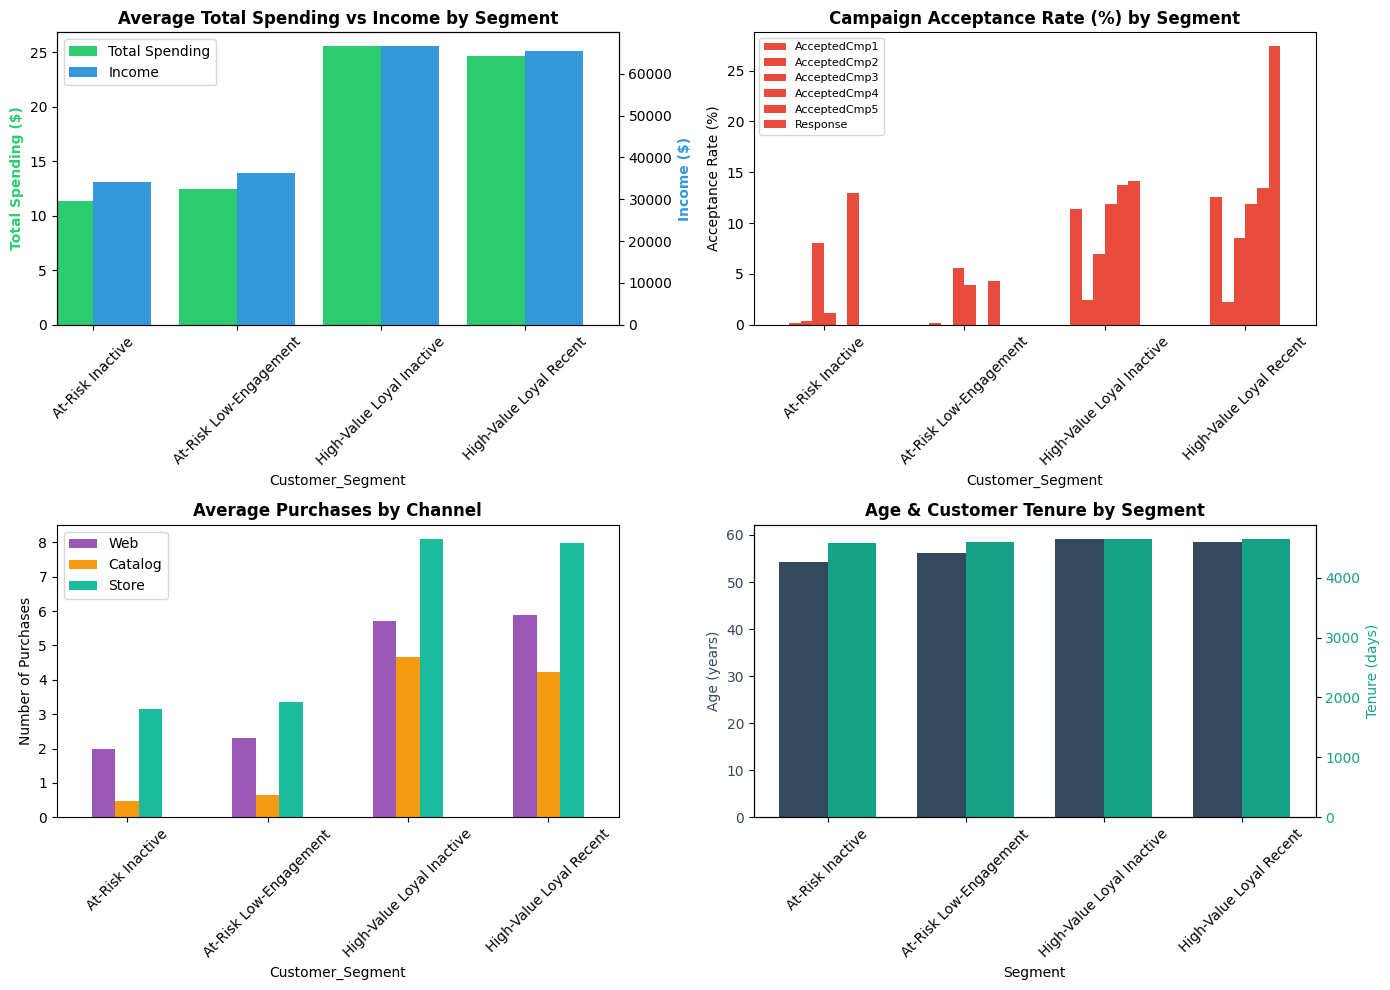

In [18]:
# Create visualizations comparing segments
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Spending by segment
ax1 = axes[0, 0]
spending_data = df.groupby('Customer_Segment')[['Total_Spending', 'Income']].mean()
spending_data['Total_Spending'].plot(kind='bar', ax=ax1, color='#2ecc71', position=1, width=0.4, label='Total Spending')
ax1.set_ylabel('Total Spending ($)', color='#2ecc71', fontweight='bold')
ax1_twin = ax1.twinx()
spending_data['Income'].plot(kind='bar', ax=ax1_twin, color='#3498db', position=0, width=0.4, label='Income')
ax1_twin.set_ylabel('Income ($)', color='#3498db', fontweight='bold')
ax1.set_title('Average Total Spending vs Income by Segment', fontsize=12, fontweight='bold')
ax1.set_xticklabels(spending_data.index, rotation=45)
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Campaign response
campaign_response = df.groupby('Customer_Segment')[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response']].mean() * 100
campaign_response.plot(kind='bar', ax=axes[0, 1], color='#e74c3c')
axes[0, 1].set_title('Campaign Acceptance Rate (%) by Segment', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Acceptance Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend(loc='upper left', fontsize=8)

# Purchase channels
channel_data = df.groupby('Customer_Segment')[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].mean()
channel_data.plot(kind='bar', ax=axes[1, 0], color=['#9b59b6', '#f39c12', '#1abc9c'])
axes[1, 0].set_title('Average Purchases by Channel', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Purchases')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(['Web', 'Catalog', 'Store'])

# Age and tenure
age_tenure = df.groupby('Customer_Segment')[['Age', 'Customer_Tenure_Days']].mean()
ax2 = axes[1, 1]
x = np.arange(len(age_tenure.index))
width = 0.35
ax2.bar(x - width/2, age_tenure['Age'], width, label='Age', color='#34495e')
ax2_twin = ax2.twinx()
ax2_twin.bar(x + width/2, age_tenure['Customer_Tenure_Days'], width, label='Tenure (Days)', color='#16a085')
ax2.set_xlabel('Segment')
ax2.set_ylabel('Age (years)', color='#34495e')
ax2_twin.set_ylabel('Tenure (days)', color='#16a085')
ax2.set_title('Age & Customer Tenure by Segment', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(age_tenure.index, rotation=45)
ax2.tick_params(axis='y', labelcolor='#34495e')
ax2_twin.tick_params(axis='y', labelcolor='#16a085')

plt.tight_layout()
plt.show()

In [19]:
# Two Customer Segments Identified:

# At-Risk Segment (46.7% of customers, n=1,040)

# Lower income ($35K avg) and lower spending ($11.92 avg)
# Older demographic (55.1 years avg)
# Low campaign engagement (8.7% response rate)
# Prefer store purchases over web/catalog
# Higher web visit frequency (6.5/month) but low conversion
# High-Value Loyal Segment (53.3% of customers, n=1,189)

# Higher income ($66K avg) and 2x higher spending ($25.12 avg)
# Slightly older (58.8 years avg)
# Strong campaign engagement (20.5% response rate)
# Balanced across all purchase channels
# More selective web visitors (4.3/month) but higher conversion